# Pytrees and structured parameters

CPU companion; no accelerator is required. TPU execution not validated.

- Identify containers, leaves and structure
- Derive the matching gradient tree
- Apply corresponding leaves, not unrelated arrays
- Keep metadata separate from differentiated state

Our model has a weight vector and a bias. How do we keep each parameter paired with its gradient? We’ll store them in a small nested structure called a pytree, calculate one update by hand, and check that JAX follows the same structure. The tree is just a way to keep related values organized.

## The idea

A pytree is a nested structure whose leaves hold values such as parameters. JAX can transform the leaves while preserving the structure. This makes a model's parameter groups explicit and lets us compare the gradient tree with the parameters it differentiates.

## Match leaves by meaning as well as shape

Suppose parameters contain a dense-layer weight matrix and a bias vector. Each gradient leaf describes sensitivity to its corresponding parameter leaf. Match paths such as layer/weight and layer/bias before comparing shapes; two equal-shaped leaves can still be swapped.

Optimizer state is related but need not have exactly the parameter tree's structure. It may contain moment trees plus a scalar step counter or other metadata. A useful diagram aligns matching parameter/gradient paths and then shows the additional optimizer state separately.

When a tree operation fails, inspect structure, leaf paths, shapes and dtypes in that order. Flattening everything immediately may hide the semantic distinction that would explain the error.

### Pause and reason

Two parameter leaves have the same shape. Is swapping their gradients safe?

<details><summary>Compare your reasoning</summary>

No. Shape compatibility does not identify which parameter a derivative belongs to. Preserve tree paths and compare the result with an independently known update.

</details>

## Identify containers, leaves and structure

A pytree separates a nested container structure from its leaves. A dictionary with weight and bias keys is a tree; each array is a leaf. A leaf can itself have many numerical elements. Two leaves therefore do not mean two scalar parameters.

JAX transformations understand common dictionaries, lists and tuples. tree.flatten returns an ordered leaf list plus a tree definition that can reconstruct the original containers. Treat that definition as part of the contract, rather than manually guessing where each flattened value belongs.

```text
params
├── weight: float32[2]
└── bias: float32[]
2 leaves, 3 numerical parameter values
```

## Derive the matching gradient tree

Let’s check one example. Take $x=[2,1]$, weights $w=[1,-1]$, and bias $b=0$. The prediction is $1$, while the target is $3$, so the residual is $-2$. For squared loss, the derivative with respect to the prediction is $-4$. Multiplying by the input gives the weight gradient $-4[2,1]=[-8,-4]$; the bias gradient is $-4$.

With learning rate $0.05$, the new weights are $[1.4,-0.8]$, and the bias becomes $0.2$. The new prediction is $2.2$, the residual is $-0.8$, and the loss is $0.64$. We can compare each of these values with the gradient tree and update. This tells us more than checking only whether the loss decreased.

$$
\begin{aligned}\hat y&=2(1)+1(-1)+0=1\\L&=(1-3)^2=4\\\nabla_w L&=(-8,-4),\qquad \frac{\partial L}{\partial b}=-4\end{aligned}
$$

## Apply corresponding leaves, not unrelated arrays

tree.map can apply $p-\eta g$ to corresponding leaves in the parameter and gradient trees. The containers must agree. A missing key is a structural error; an incompatible leaf shape is a numerical contract error. A matching tree structure alone does not prove that each leaf has the correct shape.

Dictionary leaves are traversed in a deterministic key order. Do not zip unrelated dictionaries merely because they have equal lengths. Use the tree definition to preserve identity and add shape checks at model boundaries.

## Keep metadata separate from differentiated state

Trainable leaves should be appropriate floating-point arrays. A Python string such as a model name is not a floating-point parameter. Keep such configuration separate, or register a carefully designed custom structure when the model requires it.

Optimizer state is another tree with its own meaning. Its structure need not be identical to parameters. Model parameters, gradients and optimizer statistics are connected, but they are not interchangeable objects. This separation will matter in the Optax lesson and in recovery.

## Prepare the inputs

Create main.py in your lesson workspace. Add this first block; use the environment from setup.

In [1]:
import jax
import jax.numpy as jnp

These explicit inputs define the case that the later checks will verify.

## Build the computation

Append this block below the inputs in the same file.

In [2]:
params = {"weight": jnp.array([1., -1.]), "bias": jnp.array(0.)}
x = jnp.array([2., 1.])
def loss(p):
    prediction = jnp.dot(p["weight"], x) + p["bias"]
    return (prediction - 3.) ** 2

loss reads both parameter leaves. grad returns a matching gradient tree; tree.map pairs each parameter with its corresponding derivative for the update.

## Run and check the result

Append the checks, save main.py, and run python main.py from this folder using your course environment.

In [3]:
value, grads = jax.value_and_grad(loss)(params)
updated = jax.tree.map(lambda p, g: p - 0.05 * g, params, grads)
print("Before/after:", float(value), float(loss(updated)))
assert grads.keys() == params.keys()
assert loss(updated) < value

Before/after: 4.0 0.6399999260902405


Compare the output to the expected result below before making the exercise change.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
params = {"weight": jnp.array([1., -1.]), "bias": jnp.array(0.)}
x = jnp.array([2., 1.])
def loss(p):
    prediction = jnp.dot(p["weight"], x) + p["bias"]
    return (prediction - 3.) ** 2
value, grads = jax.value_and_grad(loss)(params)
updated = jax.tree.map(lambda p, g: p - 0.05 * g, params, grads)
print("Before/after:", float(value), float(loss(updated)))
assert grads.keys() == params.keys()
assert loss(updated) < value

Before/after: 4.0 0.6399999260902405


Expected: Before/after: $4.0$, approximately $0.64$.

## A gradient tree matches parameter leaves

Predict: Which weight changes more, and why?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'bar', 'labels': ['weight[0]', 'weight[1]', 'bias'], 'ylabel': 'parameter value', 'series': [{'label': 'before', 'y': [float(params['weight'][0]), float(params['weight'][1]), float(params['bias'])]}, {'label': 'after', 'y': [float(updated['weight'][0]), float(updated['weight'][1]), float(updated['bias'])]}]}

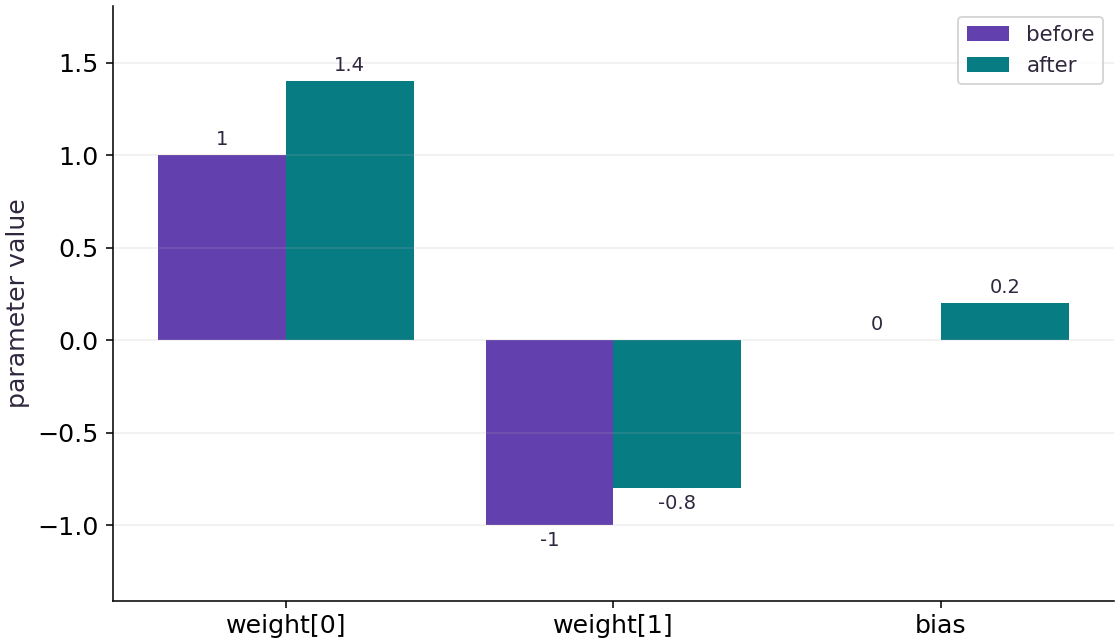

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each pair of bars compares one parameter before and after a gradient step. Read the categories as the two weight coordinates followed by the bias. The weights move from $(1,-1)$ to $(1.4,-0.8)$, and the bias moves from $0$ to $0.2$.

The second weight’s bar remains below zero, but becomes less negative. All three parameters increased; an upward update does not require the parameter itself to be positive.

### Connect it to the computation

For the input $(2,1)$, the initial prediction is $1$, below the target $3$. The parameter gradients are $(-8,-4,-4)$. Subtracting them with learning rate $0.05$ adds $(0.4,0.2,0.2)$, exactly the changes visible between the paired bars.

The updated prediction is $2.2$, so squared error falls from $4$ to $0.64$. The tree structure lets each gradient reach its corresponding parameter leaf. The chart’s vertical axis is parameter value, not loss; you need the prediction calculation to establish improvement.

## Verify every gradient leaf

Predict: Predict both weight derivatives and the bias derivative from the residual before inspecting grads.

In [7]:
assert jnp.allclose(grads["weight"],jnp.array([-8.,-4.]))
assert jnp.allclose(grads["bias"],-4.)
assert jnp.allclose(updated["weight"],jnp.array([1.4,-0.8]))
assert jnp.allclose(updated["bias"],0.2)
assert jnp.allclose(loss(updated),0.64,atol=1e-6)

Expected: All leaves agree with the hand-derived update.

This check verifies parameter identity and the actual gradient values, not just a matching container.

## Flatten and reconstruct without losing identity

Predict: What is retained by the tree definition when array values are replaced?

In [8]:
leaves,definition=jax.tree.flatten(params)
rebuilt=jax.tree.unflatten(definition,leaves)
assert jax.tree.structure(rebuilt)==jax.tree.structure(params)
assert jnp.array_equal(rebuilt["weight"],params["weight"])
assert jnp.array_equal(rebuilt["bias"],params["bias"])

Expected: The original keys and corresponding values are reconstructed.

The tree definition describes containers; leaves supply numerical values. Both are needed for reconstruction.

## Your exercise

Compute the squared norm of all gradient leaves. Verify it by adding the weight and bias contributions directly.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
norm_squared = sum(jnp.sum(g ** 2) for g in jax.tree.leaves(grads))
manual = jnp.sum(grads["weight"] ** 2) + grads["bias"] ** 2
assert jnp.allclose(norm_squared, manual)
assert jnp.allclose(norm_squared, 96.)

## Extend to a nested model · Practice

Place weight and bias under a layer dictionary and add a scalar scale parameter. Verify the derivative of scale for $s(wx+b)$.

Hint: At the starting point prediction is $1$ and residual is $-2$, so the scale derivative is $-4$.

In [11]:
# Write your attempt here.

## Reference reasoning

Nested parameter identity survives differentiation. The independent scale calculation checks the new path.

In [12]:
nested={"layer":params,"scale":jnp.array(1.)}
def nested_loss(p):
    pred=p["scale"]*(jnp.dot(p["layer"]["weight"],x)+p["layer"]["bias"])
    return (pred-3.)**2
g=jax.grad(nested_loss)(nested)
assert jax.tree.structure(g)==jax.tree.structure(nested)
assert jnp.allclose(g["scale"],-4.)

## Repair a mismatched update tree · Challenge

Remove bias from the gradient dictionary, reproduce the structural error, then restore it and verify the hand update.

Hint: Matching leaf counts is not enough; key paths matter.

In [13]:
# Write your attempt here.

## Reference reasoning

A missing bias gradient is a tree mismatch. Broadcasting weights or changing a learning rate cannot supply the missing parameter identity.

In [14]:
try:
    jax.tree.map(lambda p,g:p-0.05*g,params,{"weight":grads["weight"]})
except ValueError:
    print("Expected tree mismatch")
else:
    raise AssertionError("Expected a missing-key failure")
fixed=jax.tree.map(lambda p,g:p-0.05*g,params,grads)
assert jnp.allclose(loss(fixed),0.64,atol=1e-6)

Expected tree mismatch


## Checkpoint

What structure does `grad(loss)(params)` have?

1. One scalar regardless of parameters
2. A pytree corresponding to params
3. A list of Python source lines

## Diagnose

A missing bias gradient is a tree mismatch. Broadcasting weights or changing a learning rate cannot supply the missing parameter identity.

## Evidence

Keep the parameter/gradient tree diagram, hand-derived leaves and update, flatten/unflatten round trip, nested-scale derivative and missing-key repair.

## Carry forward

- This check verifies parameter identity and the actual gradient values, not just a matching container.
- The tree definition describes containers; leaves supply numerical values. Both are needed for reconstruction.

## Primary references

- [JAX pytrees](https://docs.jax.dev/en/latest/101/pytrees.html)